# agentcore-stock-analytics — Demo Notebook

This notebook demonstrates end-to-end invocation of the deployed agent:
1. Cognito user authentication (JWT retrieval)
2. Streaming SSE queries against the Agentcore Runtime endpoint

## Prerequisites

- The infrastructure must be deployed (see README.md)
- A Cognito test user must exist
- `pip install boto3 requests langfuse`

In [87]:
!pip install -q boto3 requests langfuse

## Configuration

Fill in the values from your Terraform outputs and Cognito user.

In [124]:
# --- FILL THESE IN ---
AWS_REGION = "us-east-1"
COGNITO_USER_POOL_ID = "<your-user-pool-id>"       # terraform output cognito_user_pool_id
COGNITO_CLIENT_ID    = "<your-client-id>"           # terraform output cognito_user_pool_client_id
RUNTIME_ID           = "<your-runtime-id>"          # from create-agent-runtime output
AWS_ACCOUNT_ID       = "<your-account-id>"

COGNITO_USERNAME = "<your-username>"
COGNITO_PASSWORD = "<your-password>"

## 1. Cognito Authentication

Authenticate against the Cognito User Pool and retrieve a JWT ID token.

In [114]:
import boto3

cognito = boto3.client("cognito-idp", region_name=AWS_REGION)

auth_response = cognito.initiate_auth(
    AuthFlow="USER_PASSWORD_AUTH",
    ClientId=COGNITO_CLIENT_ID,
    AuthParameters={
        "USERNAME": COGNITO_USERNAME,
        "PASSWORD": COGNITO_PASSWORD,
    },
)

id_token = auth_response["AuthenticationResult"]["IdToken"]
print(f"Authentication successful!")
print(f"Token type: ID Token (JWT)")
print(f"Token preview: {id_token[:80]}...")
print(f"Expires in: {auth_response['AuthenticationResult']['ExpiresIn']}s")

Authentication successful!
Token type: ID Token (JWT)
Token preview: eyJraWQiOiJualdwZDZTK2wyRng0ZlM0Zk54emN5V1pVTW4wSUM0VCtKN04xbXNIVjRrPSIsImFsZyI6...
Expires in: 3600s


## 2. Agent Invocation Helper

Helper function that sends a query to the Agentcore Runtime endpoint and streams the SSE response.

In [115]:
import json
import re
import uuid
from urllib.parse import quote

import requests


def invoke_agent(query: str, token: str) -> str:
    """Send a query to the agent and stream the SSE response. Returns the final answer."""
    agent_arn = f"arn:aws:bedrock-agentcore:{AWS_REGION}:{AWS_ACCOUNT_ID}:runtime/{RUNTIME_ID}"
    encoded_arn = quote(agent_arn, safe="")
    url = f"https://bedrock-agentcore.{AWS_REGION}.amazonaws.com/runtimes/{encoded_arn}/invocations"
    session_id = str(uuid.uuid4())

    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json",
        "X-Amzn-Bedrock-AgentCore-Runtime-Session-Id": session_id,
    }

    print(f"Query: {query}")
    print(f"Session: {session_id}")
    print("-" * 60)

    response = requests.post(url, headers=headers, json={"query": query}, stream=True, timeout=120)
    response.raise_for_status()

    full_text = ""

    for line in response.iter_lines(decode_unicode=True):
        if not line or not line.startswith("data: "):
            continue
        try:
            chunk = json.loads(line[len("data: "):])
            chunk_type = chunk.get("type", "")
            chunk_data = chunk.get("data", "")

            if chunk_type == "token" and chunk_data:
                full_text += chunk_data
                print(chunk_data, end="", flush=True)
            elif chunk_type == "error":
                print(f"\n[error] {chunk_data}")
        except json.JSONDecodeError:
            pass

    print(f"\n" + "-" * 60)
    return full_text

## 3. Query Demonstrations

### Query 1: What is the stock price for Amazon right now?

In [116]:
r1 = invoke_agent("What is the stock price for Amazon right now?", id_token)

Query: What is the stock price for Amazon right now?
Session: fa27b3de-0480-448d-ab1d-301721eb4913
------------------------------------------------------------
The current stock price for Amazon (AMZN) is **$238.38**.
------------------------------------------------------------


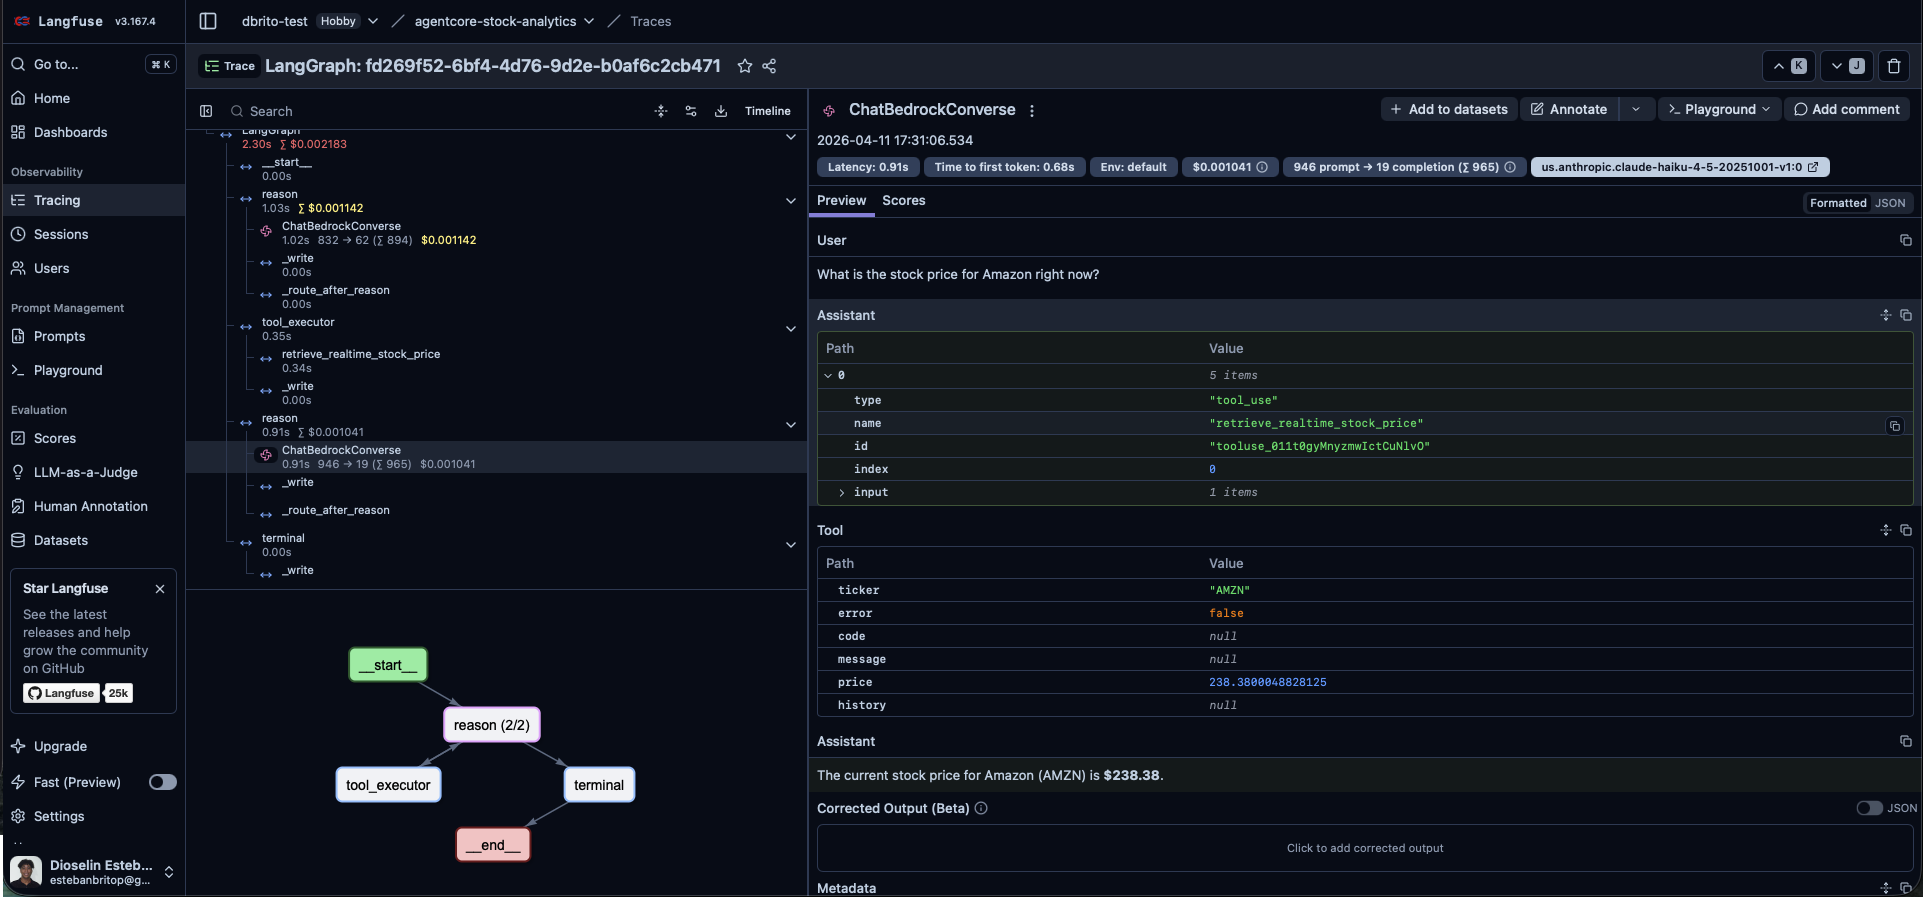

### Query 2: What were the stock prices for Amazon in Q4 last year?

In [117]:
r2 = invoke_agent("What were the stock prices for Amazon in Q4 last year?", id_token)

Query: What were the stock prices for Amazon in Q4 last year?
Session: 80a2198d-221e-4162-9edd-b0b8010ff8f8
------------------------------------------------------------
I'll retrieve the historical stock prices for Amazon during Q4 of last year (October 1 - December 31, 2024).Here are Amazon's (AMZN) stock prices for Q4 2024 (October 1 - December 31):

**Key Statistics for Q4 2024:**
- **Starting Price (Oct 1):** $185.13
- **Ending Price (Dec 30):** $221.30
- **Quarter Gain:** +$36.17 (+19.5%)
- **Highest Price:** $232.93 (Dec 16)
- **Lowest Price:** $180.80 (Oct 7)

**Monthly Overview:**
- **October:** Started at $185.13, ended at $186.40 (slight gain of 0.7%)
- **November:** Started at $197.93, ended at $207.89 (strong performance with 5% gain)
- **December:** Started at $210.71, ended at $221.30 (continued strength with 5% gain)

Amazon had a very strong Q4 performance, with significant gains particularly in November and December. The stock rose nearly 20% over the quarter, starting

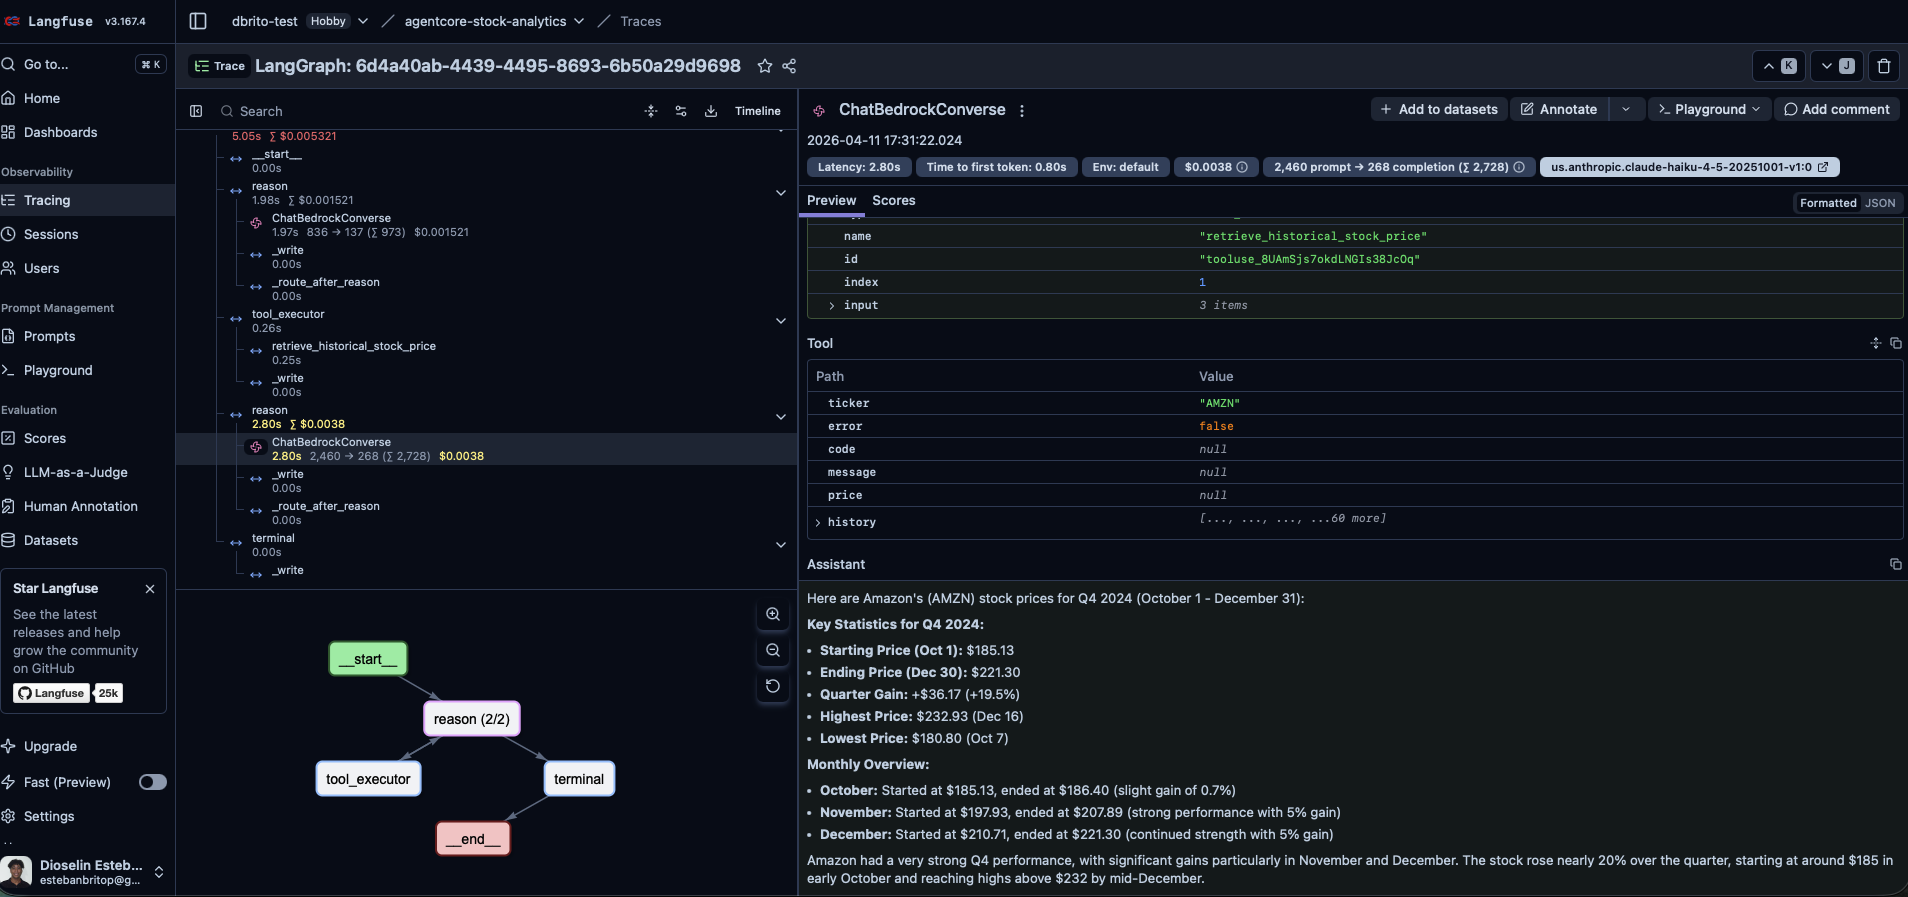

### Query 3: Compare Amazon's recent stock performance to what analysts predicted in their reports

In [118]:
r3 = invoke_agent(
    "Compare Amazon's recent stock performance to what analysts predicted in their reports",
    id_token,
)

Query: Compare Amazon's recent stock performance to what analysts predicted in their reports
Session: 6597dada-faf7-4acd-aa68-267bf8cbb3b7
------------------------------------------------------------
I'll help you compare Amazon's recent stock performance to analyst predictions. Let me gather the relevant information.Let me search for more specific analyst target prices and recent performance data:## Amazon Stock Performance Comparison

Based on the available data, here's what I found:

### **Current Stock Price**
- **Today's Price: $238.38** (as of the latest data)

### **Recent Performance (Last 4 Months)**
Amazon has shown strong recovery and growth:
- **October 1, 2024:** $185.13
- **January 31, 2025:** $237.68
- **Recent High:** $242.06 (February 4, 2025)
- **Year-to-date gain (from Oct 1):** ~28.3% increase

### **Long-term Context (From Amazon's Reports)**
According to Amazon's stock price performance data:
- **2024 Year-end position:** Stock reached $237 (normalized basis from 

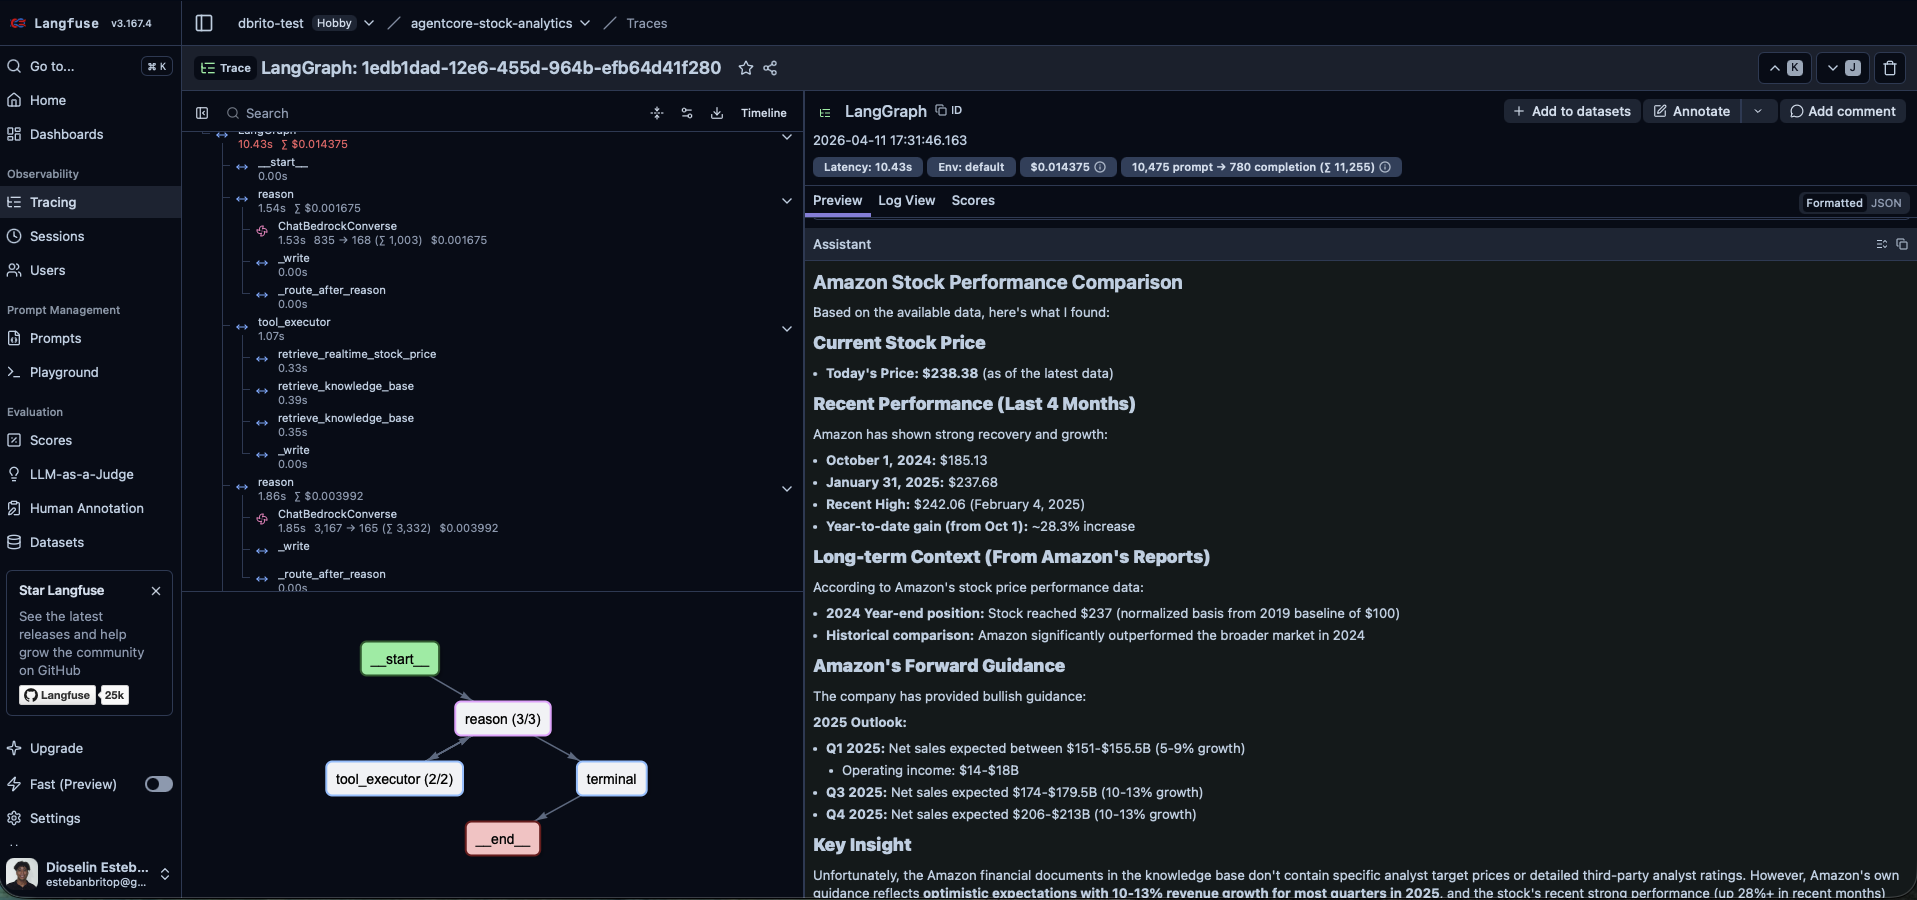

### Query 4: I'm researching AMZN — give me the current price and any relevant information about their AI business

In [119]:
r4 = invoke_agent(
    "I'm researching AMZN give me the current price and any relevant information about their AI business",
    id_token,
)

Query: I'm researching AMZN give me the current price and any relevant information about their AI business
Session: dfec1b87-246b-4c56-a44d-473526d076db
------------------------------------------------------------
I'll get you the current AMZN price and search for information about their AI business.## AMZN Current Price
**$238.38** (as of now)

## Amazon's AI Business - Key Information

Amazon has a comprehensive and rapidly growing AI business across multiple areas:

### **AI Infrastructure & Chips:**
- **Trainium2**: A custom AI chip that's fully subscribed and grown 150% quarter over quarter, now a multi-billion-dollar business
- **Amazon Nova**: Amazon's own frontier models designed to provide lower cost and latency for customer applications
- **Project Rainier**: A massive AI compute cluster with nearly 500,000 Trainium2 chips built to develop and deploy Anthropic's Claude AI models
- Adding 3.8+ gigawatts of capacity in the past 12 months to support strong AI demand

### **AI Se

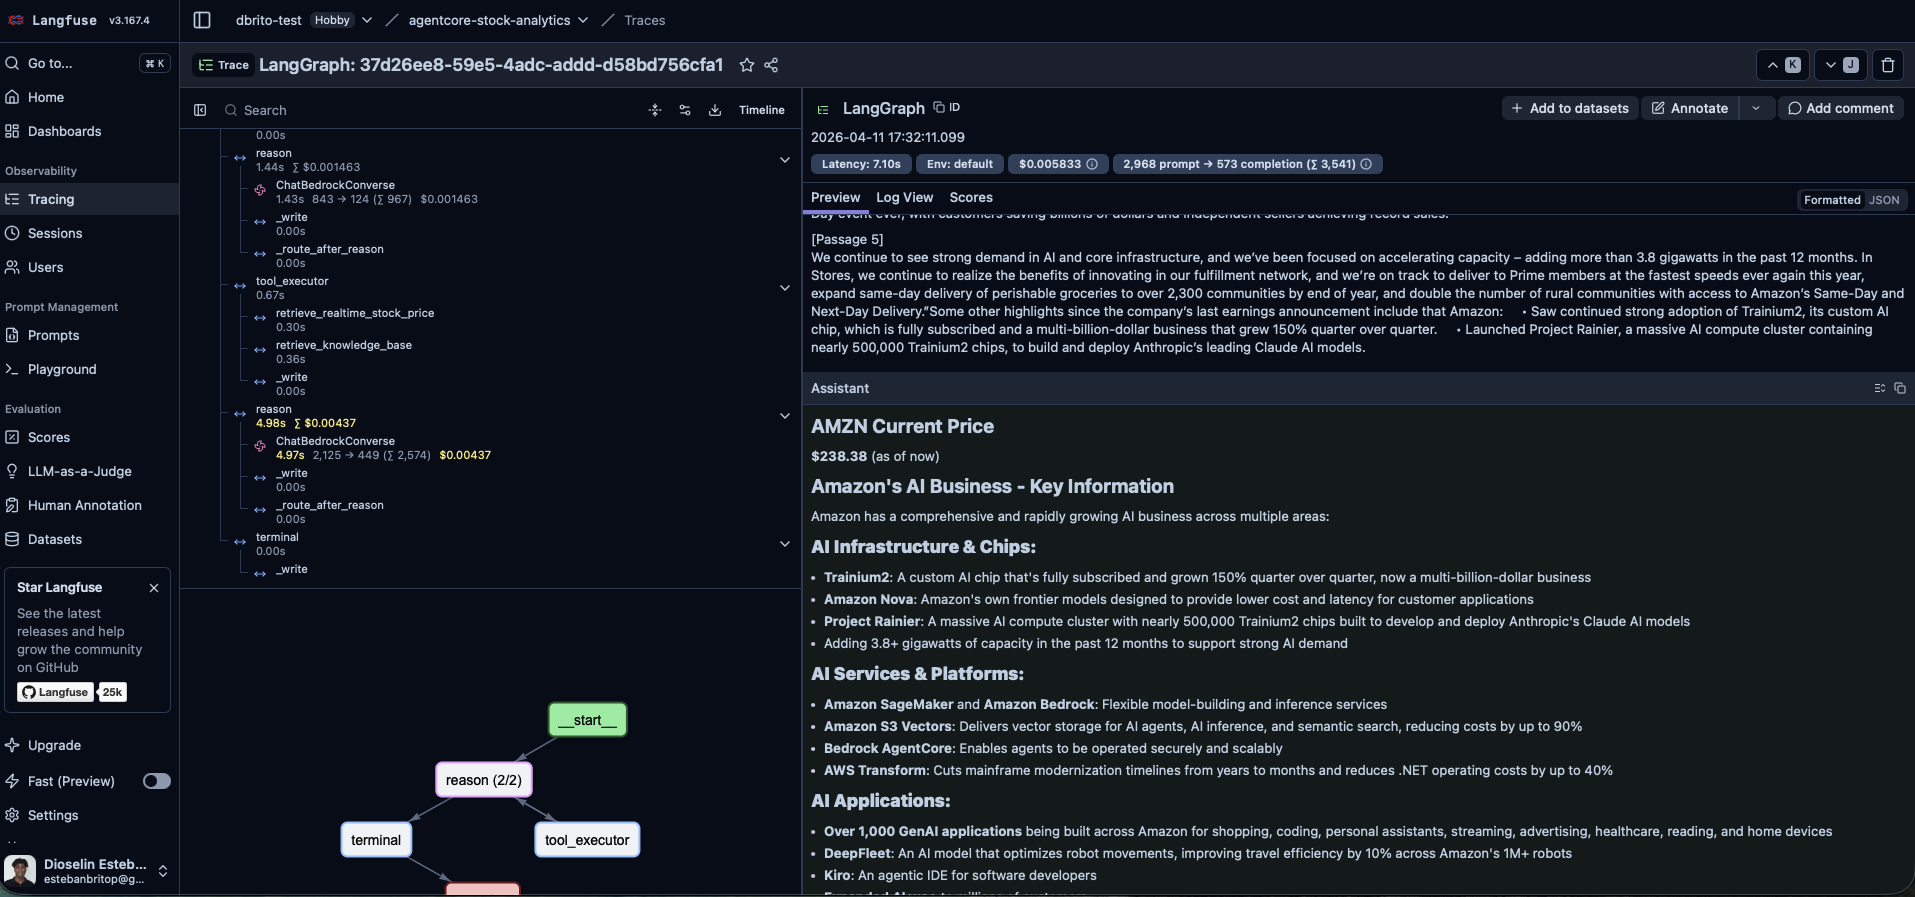

### Query 5: What is the total amount of office space Amazon owned in North America in 2024?

In [120]:
r5 = invoke_agent(
    "What is the total amount of office space Amazon owned in North America in 2024?",
    id_token,
)

Query: What is the total amount of office space Amazon owned in North America in 2024?
Session: 28c57765-4446-4048-bed0-0cd7dbb5b674
------------------------------------------------------------
I'll search Amazon's financial documents for information about their office space in North America for 2024.Based on Amazon's financial documents, **as of December 31, 2024, Amazon owned 9,104 thousand square feet (or approximately 9.1 million square feet) of office space in North America**.

This information comes from Amazon's properties breakdown, which shows:
- **Office space owned in North America: 9,104,000 square feet**
- In addition, Amazon leased 29,551,000 square feet of office space in North America

So the total office space (owned + leased) in North America was approximately 38.7 million square feet as of the end of 2024, with 9.1 million being owned and 29.6 million being leased.
------------------------------------------------------------


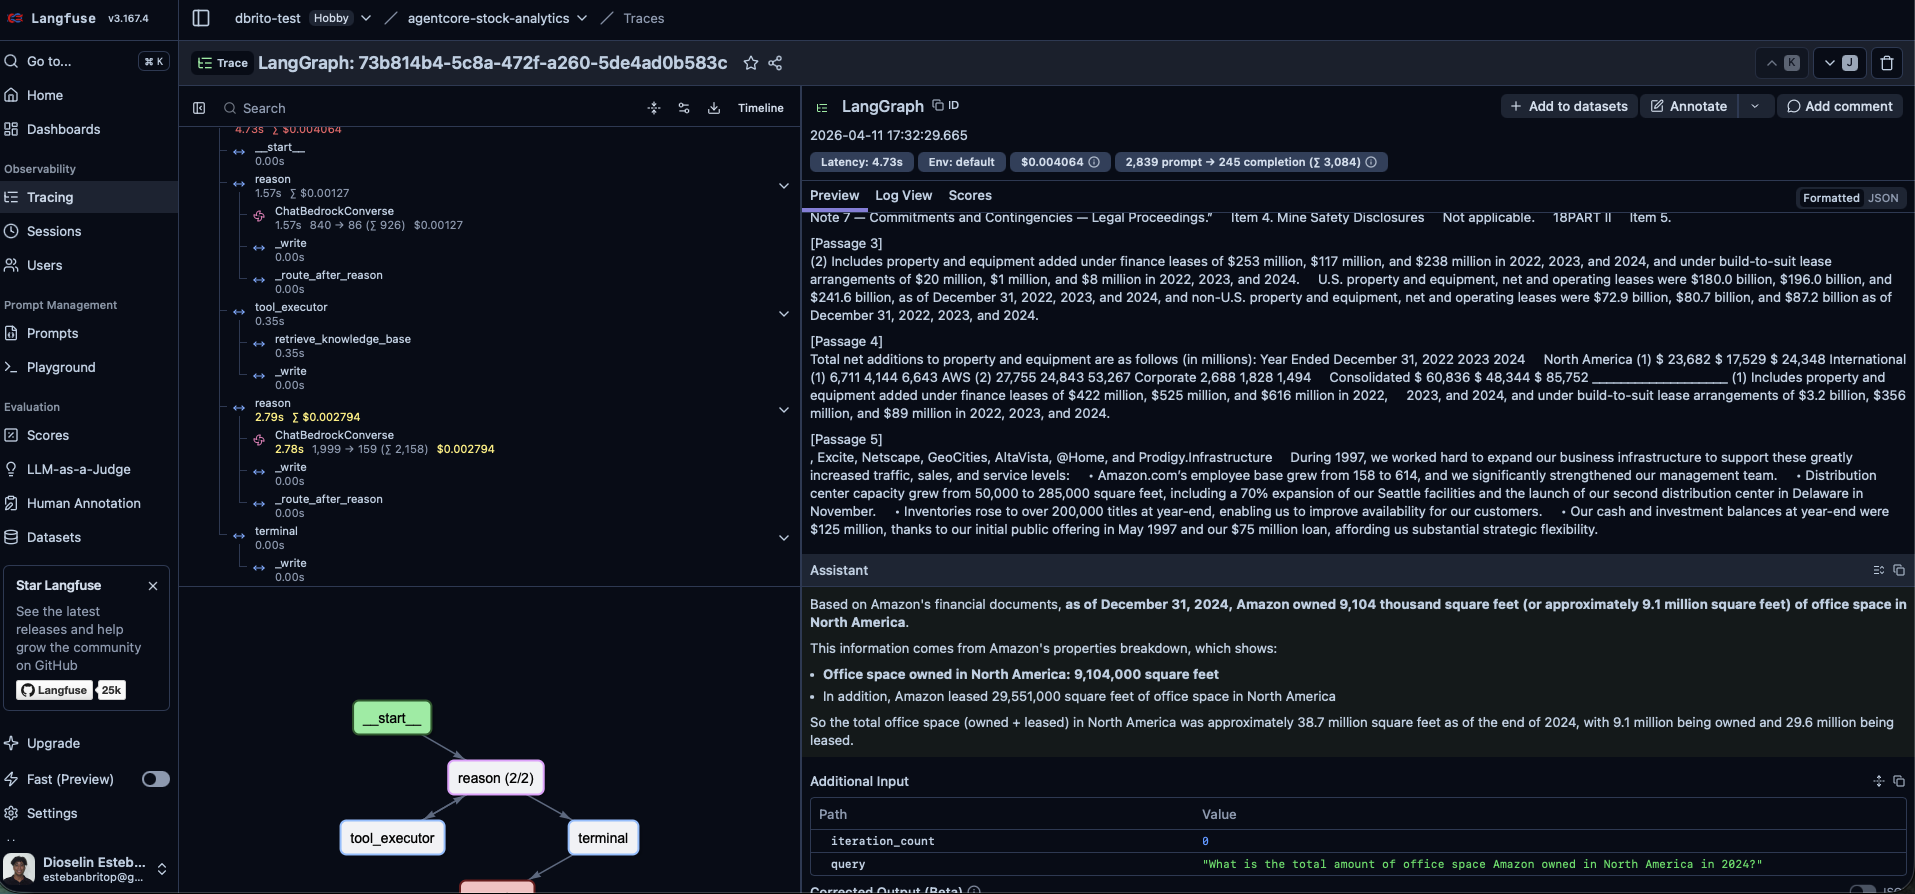